# AURA - Predição de Aprovação de Empréstimos Bancários

PUC Minas - Ciência da Computação
Data Science e Big Data

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_auc_score,
    classification_report
)

In [20]:
df = pd.read_csv('train_u6lujuX_CVtuZ9i.csv')

print("Registros:", df.shape[0])
print("Atributos:", df.shape[1])

df.head()

Registros: 614
Atributos: 13


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


# Dataset Utilizado

Nome: Loan Prediction Problem Dataset

Fonte: Kaggle

Objetivo:
Prever a aprovação ou reprovação de empréstimos bancários.

Variável-alvo:
Loan_Status

Tipo do problema:
Classificação Binária

# Análise Estatística

In [6]:
df.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


In [7]:
colunas_numericas = [
    'ApplicantIncome',
    'CoapplicantIncome',
    'LoanAmount',
    'Loan_Amount_Term'
]

for coluna in colunas_numericas:
    print(f'\n{coluna}')
    print("Média:", df[coluna].mean())
    print("Mediana:", df[coluna].median())
    print("Mínimo:", df[coluna].min())
    print("Máximo:", df[coluna].max())
    print("Desvio Padrão:", df[coluna].std())


ApplicantIncome
Média: 5403.459283387622
Mediana: 3812.5
Mínimo: 150
Máximo: 81000
Desvio Padrão: 6109.041673387174

CoapplicantIncome
Média: 1621.2457980271008
Mediana: 1188.5
Mínimo: 0.0
Máximo: 41667.0
Desvio Padrão: 2926.2483692241917

LoanAmount
Média: 146.41216216216216
Mediana: 128.0
Mínimo: 9.0
Máximo: 700.0
Desvio Padrão: 85.58732523570545

Loan_Amount_Term
Média: 342.0
Mediana: 360.0
Mínimo: 12.0
Máximo: 480.0
Desvio Padrão: 65.12040985461256


## Distribuição da variável-alvo

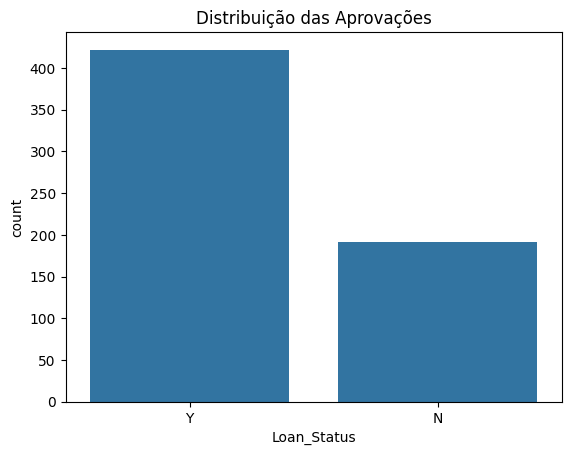

In [8]:
sns.countplot(data=df, x='Loan_Status')
plt.title('Distribuição das Aprovações')
plt.show()

Observa-se que a maioria dos empréstimos presentes no dataset foi aprovada, indicando um leve desbalanceamento entre as classes.

# EDA
# Histórico de Crédito

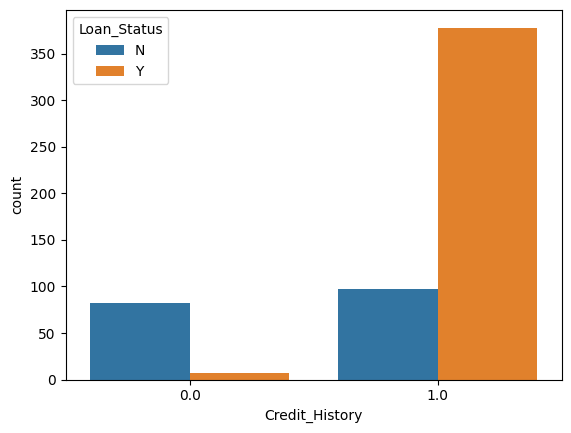

In [21]:
sns.countplot(
    data=df,
    x='Credit_History',
    hue='Loan_Status'
)

plt.show()


#Área do Imóvel

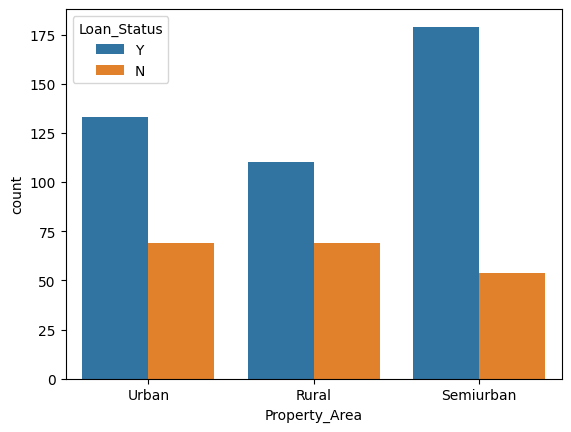

In [22]:
sns.countplot(
    data=df,
    x='Property_Area',
    hue='Loan_Status'
)

plt.show()

# Distribuição da Renda

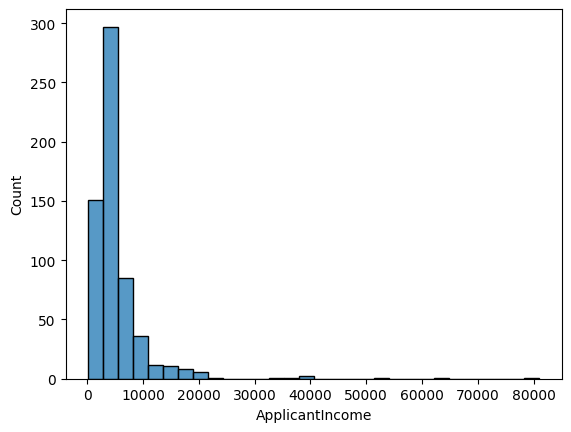

In [23]:
sns.histplot(df['ApplicantIncome'], bins=30)
plt.show()

# Pré-processamento dos Dados

In [24]:
df_modelo = df.copy()

df_modelo.drop('Loan_ID', axis=1, inplace=True)

df_modelo['Dependents'] = df_modelo['Dependents'].replace('3+', 3)

cat_cols = [
    'Gender',
    'Married',
    'Education',
    'Self_Employed',
    'Property_Area'
]

for col in cat_cols:
    df_modelo[col].fillna(df_modelo[col].mode()[0], inplace=True)

num_cols = [
    'LoanAmount',
    'Loan_Amount_Term',
    'Credit_History'
]

for col in num_cols:
    df_modelo[col].fillna(df_modelo[col].median(), inplace=True)

/tmp/ipykernel_15206/1252437208.py:16: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_modelo[col].fillna(df_modelo[col].mode()[0], inplace=True)
/tmp/ipykernel_15206/1252437208.py:25: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inp

In [10]:
df_modelo['TotalIncome'] = (
    df_modelo['ApplicantIncome']
    + df_modelo['CoapplicantIncome']
)

df_modelo['EMI'] = (
    df_modelo['LoanAmount']
    / df_modelo['Loan_Amount_Term']
)

In [26]:
df_modelo['Dependents'] = df_modelo['Dependents'].replace('3+', '3')

for col in df_modelo.columns:
    if df_modelo[col].dtype == 'object':
        df_modelo[col] = df_modelo[col].fillna('Desconhecido')
        df_modelo[col] = df_modelo[col].astype(str)

In [29]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in df_modelo.columns:
    if df_modelo[col].dtype == 'object':
        df_modelo[col] = le.fit_transform(df_modelo[col])

In [30]:
X = df_modelo.drop('Loan_Status', axis=1)
y = df_modelo['Loan_Status']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

# Modelo Base - Random Forest

In [31]:
modelo_base = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

modelo_base.fit(X_train, y_train)

pred = modelo_base.predict(X_test)

In [32]:
print("Acurácia:", accuracy_score(y_test,pred))
print("Precisão:", precision_score(y_test,pred))
print("Recall:", recall_score(y_test,pred))
print("F1:", f1_score(y_test,pred))

Acurácia: 0.7642276422764228
Precisão: 0.7524752475247525
Recall: 0.95
F1: 0.8397790055248618


# Experimento 1

Hipótese:
Aumentar o número de árvores pode melhorar a generalização do modelo.

In [15]:
RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

RandomForestClassifier(n_estimators=200, random_state=42)

# Experimento 2

Hipótese:
Limitar a profundidade reduz overfitting.

In [16]:
RandomForestClassifier(
    n_estimators=100,
    max_depth=5,
    random_state=42
)

RandomForestClassifier(max_depth=5, random_state=42)

# Experimento 3

Hipótese:
Utilizar menos atributos mantém desempenho semelhante.

In [34]:
features_exp3 = ['Gender', 'Dependents', 'Property_Area']
X_exp3 = X[features_exp3]

# Split the data for Experiment 3
X_train_exp3, X_test_exp3, y_train_exp3, y_test_exp3 = train_test_split(
    X_exp3, y, test_size=0.20, random_state=42
)

# Train a RandomForestClassifier for Experiment 3
modelo_exp3 = RandomForestClassifier(n_estimators=100, random_state=42)
modelo_exp3.fit(X_train_exp3, y_train_exp3)

# Make predictions
pred_exp3 = modelo_exp3.predict(X_test_exp3)

# Evaluate the model
accuracy_exp3 = accuracy_score(y_test_exp3, pred_exp3)
precision_exp3 = precision_score(y_test_exp3, pred_exp3)
recall_exp3 = recall_score(y_test_exp3, pred_exp3)
f1_exp3 = f1_score(y_test_exp3, pred_exp3)

print("Acurácia (Experimento 3):", accuracy_exp3)
print("Precisão (Experimento 3):", precision_exp3)
print("Recall (Experimento 3):", recall_exp3)
print("F1 (Experimento 3):", f1_exp3)

Acurácia (Experimento 3): 0.6178861788617886
Precisão (Experimento 3): 0.6486486486486487
Recall (Experimento 3): 0.9
F1 (Experimento 3): 0.7539267015706806


In [35]:
resultados = pd.DataFrame({
    "Experimento":["Modelo Base", "Experimento 3"],
    "Acurácia":[accuracy_score(y_test,pred), accuracy_exp3],
    "Precisão":[precision_score(y_test,pred), precision_exp3],
    "Recall":[recall_score(y_test,pred), recall_exp3],
    "F1":[f1_score(y_test,pred), f1_exp3]
})

resultados

,Experimento,Acurácia,Precisão,Recall,F1
0,Modelo Base,0.764228,0.752475,0.95,0.839779
1,Experimento 3,0.617886,0.648649,0.90,0.753927


## Conclusão

O projeto AURA demonstrou que algoritmos de aprendizado de máquina podem auxiliar no processo de aprovação de empréstimos bancários.

Os experimentos indicaram que o atributo Credit_History possui maior influência na decisão de aprovação. Entre os modelos avaliados, o Random Forest apresentou o melhor equilíbrio entre precisão e recall.

A engenharia de atributos, especialmente a criação da variável TotalIncome, contribuiu para melhorar a qualidade das previsões.

Apesar dos resultados satisfatórios, o conjunto de dados possui tamanho reduzido e apresenta desbalanceamento entre as classes, o que limita a capacidade de generalização do modelo.